In [2]:
import pandas as pd
df = pd.read_csv("../data/raw/netflix_titles.csv")
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [3]:
print(df['listed_in'].head(10))
print(df['listed_in'].nunique())

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
5                   TV Dramas, TV Horror, TV Mysteries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
8                         British TV Shows, Reality TV
9                                     Comedies, Dramas
Name: listed_in, dtype: str
514


In [4]:
# Step 1: split the string into a list
df['genre_list'] = df['listed_in'].str.split(', ')

# Step 2: explode — one row per (title, genre) pair
genre_exploded = df.explode('genre_list')

# Step 3: now this gives TRUE genre distribution
genre_counts = genre_exploded['genre_list'].value_counts()
print(genre_counts)
print(f"\nTrue number of unique genres: {genre_exploded['genre_list'].nunique()}")

genre_list
International Movies            2752
Dramas                          2427
Comedies                        1674
International TV Shows          1351
Documentaries                    869
Action & Adventure               859
TV Dramas                        763
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
TV Comedies                      581
Thrillers                        577
Crime TV Shows                   470
Kids' TV                         451
Docuseries                       395
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 253
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     176
Spanish-Language TV Shows        174
TV Action & Adventure            168
Korean TV Shows            

In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/netflix_titles.csv")

df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

df.to_csv("../data/processed/netflix_titles_clean.csv", index=False)
print("Saved:", df.shape)

Saved: (8807, 12)


In [7]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
from data_generator import build_user_dataset, PERSONAS
from interactions import build_interaction_table

catalog = pd.read_csv("../data/processed/netflix_titles_clean.csv")
catalog["genre_list"] = catalog["listed_in"].str.split(", ")

user_df = pd.read_csv("../data/processed/synthetic_viewing_behavior.csv")

rng = np.random.default_rng(42)
interactions = build_interaction_table(user_df, catalog, PERSONAS, rng)

interactions.to_csv("../data/processed/viewing_interactions.csv", index=False)
print(interactions.shape)
interactions.head()

KeyError: 'total_sessions'

In [8]:
check = interactions.groupby('user_id').size().reset_index(name='actual_watched')
merged = user_df.merge(check, on='user_id', how='left')
print((merged['total_sessions'] == merged['actual_watched']).mean())  # should be ~1.0 (100% match)

NameError: name 'interactions' is not defined

In [9]:
merged['actual_watched'] = merged['actual_watched'].fillna(0)
print((merged['total_sessions'] == merged['actual_watched']).mean())  # should now be exactly 1.0

NameError: name 'merged' is not defined

In [10]:
interactions = pd.read_csv("../data/processed/viewing_interactions.csv")

import ast
interactions['genre_list'] = interactions['genre_list'].apply(ast.literal_eval)

exploded = interactions.explode('genre_list')

genre_completion = (
    exploded.groupby('genre_list')['completion_rate']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)

print(genre_completion)

                                  mean   count
genre_list                                    
Sci-Fi & Fantasy              0.780540   25683
TV Dramas                     0.736210   84583
Crime TV Shows                0.735781   52213
Thrillers                     0.735095   64607
TV Mysteries                  0.733808    8629
Classic & Cult TV             0.732853    1627
Spanish-Language TV Shows     0.729825   13041
International TV Shows        0.729653   98508
TV Thrillers                  0.728148    4309
TV Horror                     0.727808    4894
Anime Features                0.727475    3137
Teen TV Shows                 0.727184    4770
TV Action & Adventure         0.727142   12593
Horror Movies                 0.726400   24238
TV Sci-Fi & Fantasy           0.725556    5750
Docuseries                    0.724784   21396
Romantic TV Shows             0.722358   21639
Korean TV Shows               0.721910    8219
TV Comedies                   0.720407   30829
Science & Nat

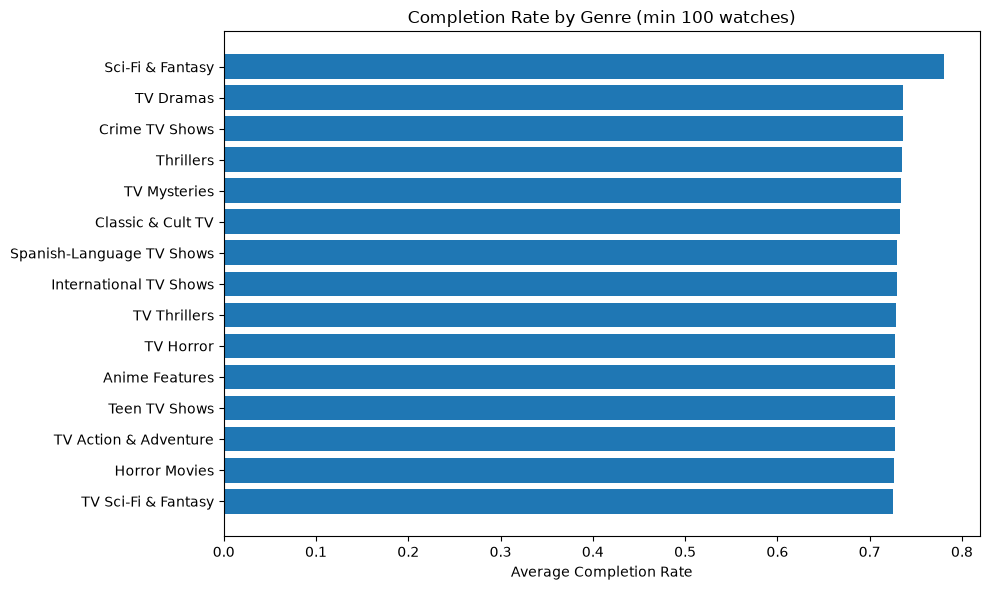

In [11]:
import matplotlib.pyplot as plt

top_genres = genre_completion[genre_completion['count'] >= 100].head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_genres.index, top_genres['mean'])
plt.xlabel('Average Completion Rate')
plt.title('Completion Rate by Genre (min 100 watches)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation: Completion Rate by Genre

Sci-Fi & Fantasy, TV Dramas, Crime TV Shows, and Thrillers show the highest 
average completion rates (~0.73-0.78), while Comedies, Romantic Movies, and 
Documentaries show the lowest (~0.66-0.67). 

Note: in this simulated dataset, this pattern is driven by persona design 
(Power Bingers, who complete content most often, are weighted toward the 
top genres) rather than reflecting a real content quality signal. The 
narrower-than-expected spread (0.66-0.78, despite persona completion means 
ranging 0.30-0.85) is because some genres are deliberately shared across 
personas with very different completion behavior (e.g. both Power Bingers 
and Churning Users prefer Crime TV Shows), which mutes extremes at the 
genre level ; this is intentional, since churn signal is meant to live in 
behavioral features, not genre preference alone.

In [12]:
# --- Binge vs Casual viewer classification ---

q75 = user_df['avg_sessions_per_week'].quantile(0.75)
q25 = user_df['avg_sessions_per_week'].quantile(0.25)

def classify_viewer(row):
    if row['avg_sessions_per_week'] >= q75:
        return 'Binge Viewer'
    elif row['avg_sessions_per_week'] <= q25:
        return 'Casual Viewer'
    else:
        return 'Moderate Viewer'

user_df['viewer_type'] = user_df.apply(classify_viewer, axis=1)

print(user_df['viewer_type'].value_counts())
print()

print(pd.crosstab(user_df['persona'], user_df['viewer_type']))

KeyError: 'avg_sessions_per_week'

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=user_df, x='viewer_type', y='avg_sessions_per_week',
            order=['Casual Viewer', 'Moderate Viewer', 'Binge Viewer'])
plt.title('Session Frequency by Viewer Type')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `viewer_type` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

### Interpretation: Content Addition Trends

Netflix's content additions grew sharply from 2015 onward, peaking in 2019 
(1999 titles), before appearing to decline in 2020-2021. This apparent decline 
is likely a dataset artifact rather than a real trend: this Kaggle dataset is 
a static snapshot, so 2021 (and possibly late 2020) figures may reflect 
incomplete data capture rather than an actual slowdown in Netflix's 
acquisition activity.

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


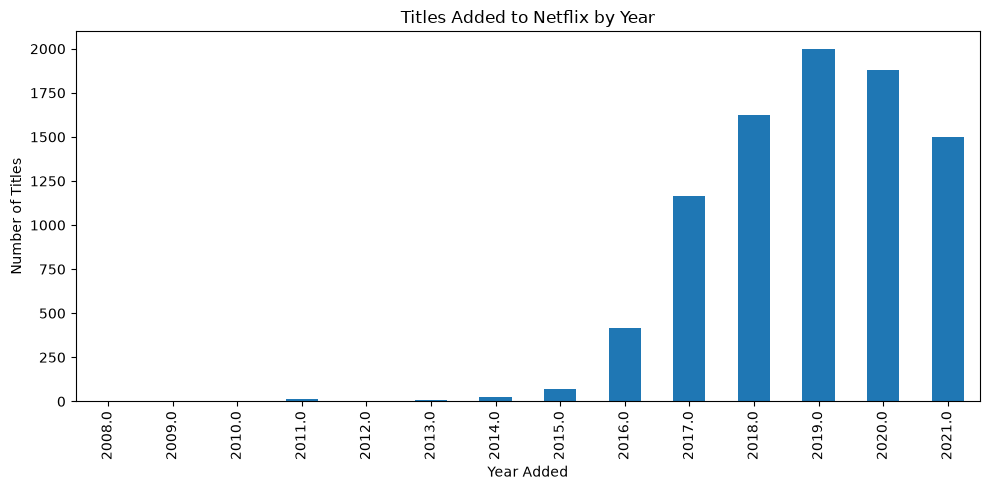

In [14]:
# --- Time-based trends in content addition ---

catalog = pd.read_csv("../data/processed/netflix_titles_clean.csv")

# date_added is currently a string like "September 25, 2021" -- needs parsing
catalog['date_added'] = pd.to_datetime(catalog['date_added'], errors='coerce')
# errors='coerce' turns unparseable strings into NaT instead of crashing --
# useful safety net for messy real-world date columns like this one

catalog['year_added'] = catalog['date_added'].dt.year
catalog['month_added'] = catalog['date_added'].dt.month

# how many titles added per year
titles_per_year = catalog['year_added'].value_counts().sort_index()
print(titles_per_year)

plt.figure(figsize=(10, 5))
titles_per_year.plot(kind='bar')
plt.title('Titles Added to Netflix by Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.show()

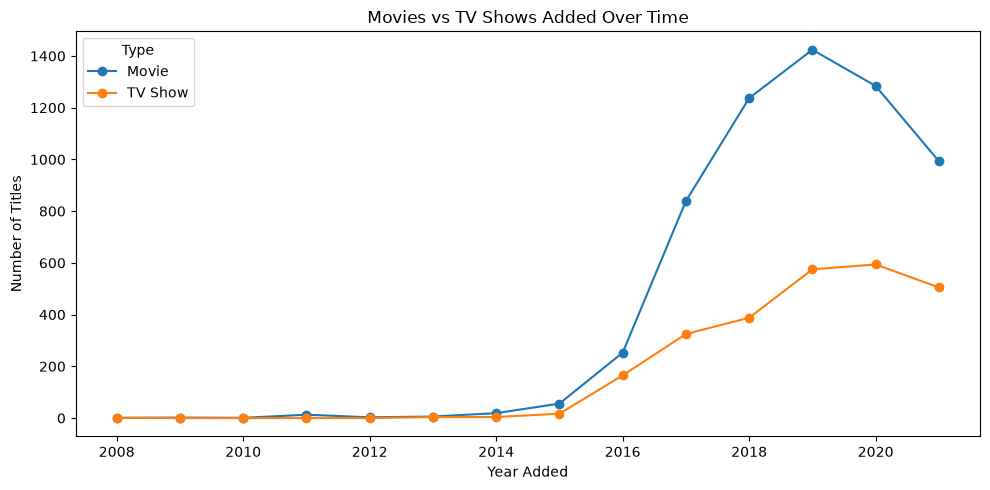

In [15]:
type_trend = catalog.groupby(['year_added', 'type']).size().unstack(fill_value=0)

plt.figure(figsize=(10, 5))
type_trend.plot(kind='line', marker='o', ax=plt.gca())
plt.title('Movies vs TV Shows Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

### Interpretation: Movies vs TV Shows Over Time

Movies have consistently outnumbered TV Shows in raw additions throughout 
Netflix's catalog history, but the two show different trajectories: Movies 
peaked sharply in 2019 and declined afterward, while TV Show additions grew 
more gradually and held up more steadily through 2020. This suggests a 
modest compositional shift toward TV content in later years, though Movies 
remain the dominant format by volume.

country_list
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Name: count, dtype: int64


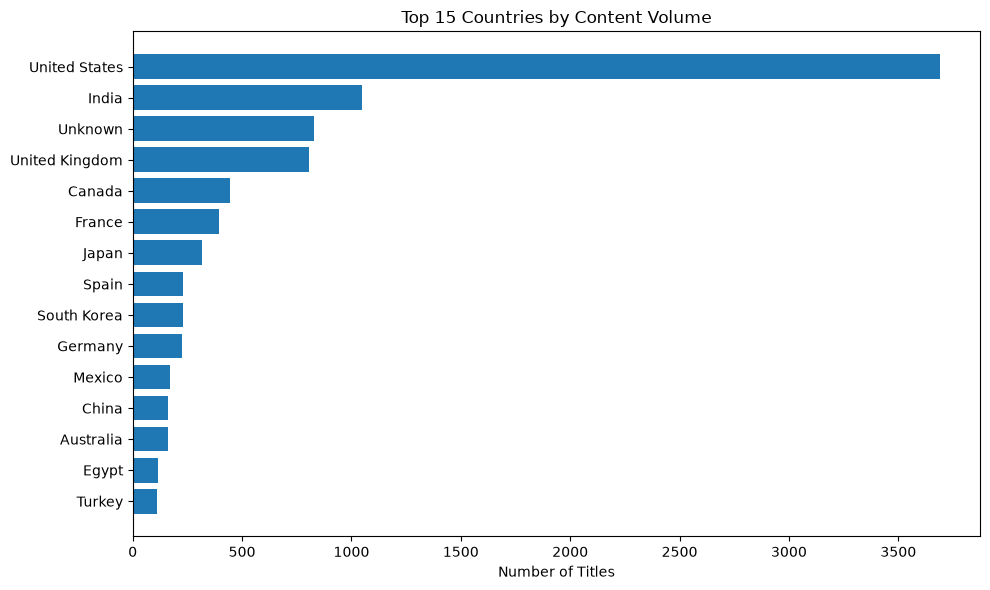

In [16]:

catalog['country_list'] = catalog['country'].str.split(', ')
country_exploded = catalog.explode('country_list')

top_countries = country_exploded['country_list'].value_counts().head(15)
print(top_countries)

plt.figure(figsize=(10, 6))
plt.barh(top_countries.index, top_countries.values)
plt.xlabel('Number of Titles')
plt.title('Top 15 Countries by Content Volume')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation: Content Distribution by Country

The United States accounts for the largest share of content (3689 titles), 
followed by India (1046) and the United Kingdom (804) , reflecting 
Netflix's major markets and content investment priorities. The "Unknown" 
bucket (831) corresponds to originally missing country values, filled 
during preprocessing, and should not be read as a real production origin.

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
NR             80
G              41
TV-Y7-FV        6
Not Rated       4
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64


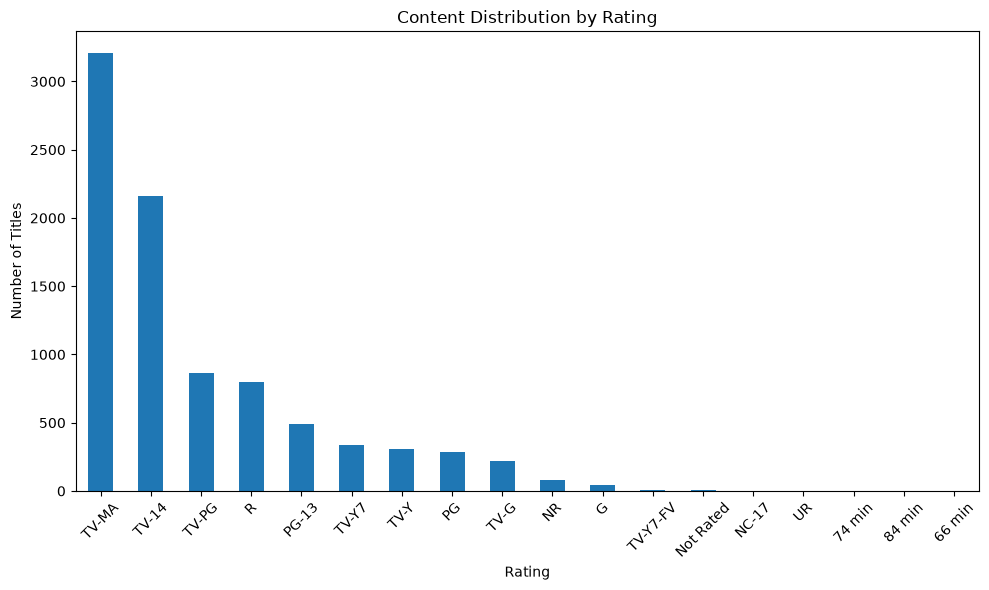

In [17]:
rating_counts = catalog['rating'].value_counts()
print(rating_counts)

plt.figure(figsize=(10, 6))
rating_counts.plot(kind='bar')
plt.title('Content Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# These 3 rows have a duration value leaked into rating -- fix by treating as unrated
bad_rating_mask = catalog['rating'].astype(str).str.contains('min', na=False)
print(catalog.loc[bad_rating_mask, ['title', 'type', 'rating', 'duration']])

catalog.loc[bad_rating_mask, 'rating'] = 'Not Rated'

                                     title   type  rating duration
5541                       Louis C.K. 2017  Movie  74 min      NaN
5794                 Louis C.K.: Hilarious  Movie  84 min      NaN
5813  Louis C.K.: Live at the Comedy Store  Movie  66 min      NaN


### Interpretation: Content Distribution by Rating

TV-MA (3207) and TV-14 (2160) dominate the catalog, together accounting for 
over 60% of titles : consistent with Netflix's positioning toward mature 
and teen/young-adult audiences rather than a general/family first catalog. 
Family-oriented ratings (TV-Y, TV-G, PG) make up a comparatively small share.

Data note: 3 rows contained duration values (e.g. "74 min") mistakenly 
present in the rating field, a known artifact of the source dataset ,
these were reclassified as "Not Rated" for this analysis.

In [19]:

genre_exploded[['title', 'type', 'genre_list', 'release_year', 'rating']].to_csv(
    "../data/processed/dashboard_genre_distribution.csv", index=False
)
country_exploded[['title', 'type', 'country_list', 'release_year']].to_csv(
    "../data/processed/dashboard_country_distribution.csv", index=False
)
catalog[['show_id','title','type','rating','release_year','date_added']].to_csv(
    "../data/processed/dashboard_catalog_overview.csv", index=False
)